In [1]:
#We will install and import all the required libraries such as pandas, mixtend, matplotlib, networkx.
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [3]:
data = pd.read_csv("/home/kelvin/Assignments/Assignment 2/Dataset 2/Dataset2.csv")

print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
transactions = data.groupby('Age')[
    'Outcome'].apply(list).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.head()

,0,1
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True


In [5]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

print(frequent_itemsets.head())

    support itemsets
0  0.980769      (0)
1  0.865385      (1)
2  0.846154   (0, 1)


In [6]:
rules = association_rules(
    frequent_itemsets, metric="confidence", min_threshold=0.3)

print(rules.head())

  antecedents consequents  antecedent support  consequent support   support  \
0         (0)         (1)            0.980769            0.865385  0.846154   
1         (1)         (0)            0.865385            0.980769  0.846154   

   confidence     lift  representativity  leverage  conviction  zhangs_metric  \
0    0.862745  0.99695               1.0 -0.002589    0.980769      -0.137255   
1    0.977778  0.99695               1.0 -0.002589    0.865385      -0.022222   

    jaccard  certainty  kulczynski  
0  0.846154  -0.019608    0.920261  
1  0.846154  -0.155556    0.920261  


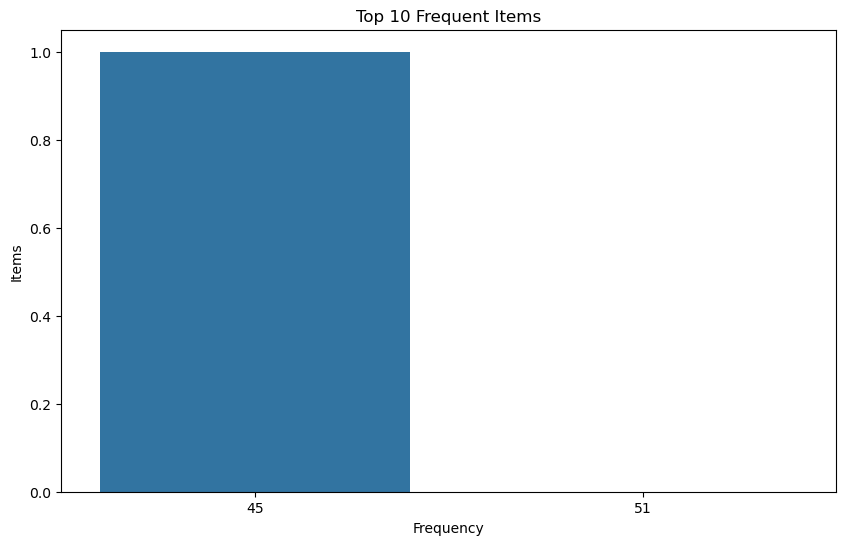

In [7]:
item_frequencies = df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=item_frequencies.head(10).values,
            y=item_frequencies.head(10).index)
plt.title('Top 10 Frequent Items')
plt.xlabel('Frequency')
plt.ylabel('Items')
plt.show()

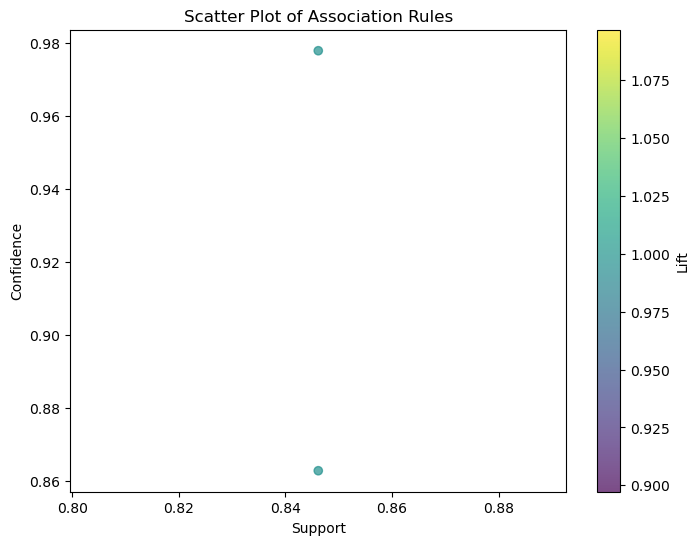

In [8]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rules['support'], rules['confidence'],
                      c=rules['lift'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Scatter Plot of Association Rules')
plt.show()

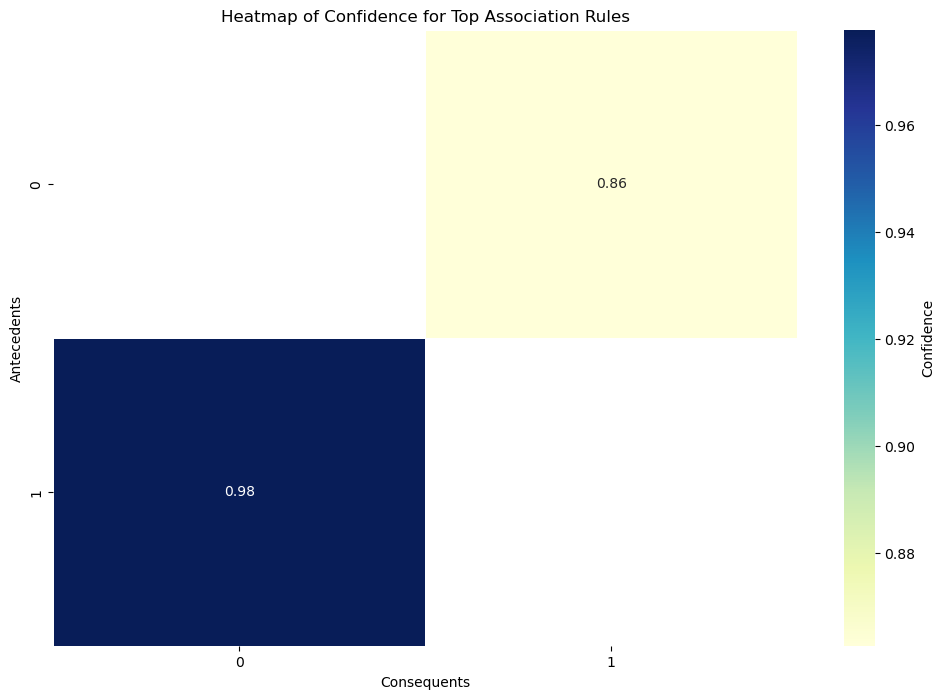

In [9]:
rules['antecedents_str'] = rules['antecedents'].apply(
    lambda x: ', '.join(map(str, x))
)
rules['consequents_str'] = rules['consequents'].apply(
    lambda x: ', '.join(map(str, x))
)

top_ants = rules.groupby('antecedents_str')['support'].sum().nlargest(10).index
top_cons = rules.groupby('consequents_str')['support'].sum().nlargest(10).index

filtered = rules[(rules['antecedents_str'].isin(top_ants)) &
                 (rules['consequents_str'].isin(top_cons))]

heatmap_data = filtered.pivot(
    index='antecedents_str', columns='consequents_str', values='confidence'
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Confidence'})
plt.title('Heatmap of Confidence for Top Association Rules')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.show()
